> Note that this won't work on data generated before 05/10/25 as I wasn't logging hyperpameters in the train-data.pkl files before this.

In [49]:
!brew install graphviz

==> Auto-updating Homebrew...
Adjust how often this is run with HOMEBREW_AUTO_UPDATE_SECS or disable with
HOMEBREW_NO_AUTO_UPDATE. Hide these hints with HOMEBREW_NO_ENV_HINTS (see `man brew`).
==> Auto-updated Homebrew!
Updated 3 taps (pwndbg/tap, homebrew/core and homebrew/cask).
==> New Formulae
addlicense: Scan directories recursively to ensure source files have license headers
aiac: Artificial Intelligence Infrastructure-as-Code Generator
aicommit2: Reactive CLI that generates commit messages for Git and Jujutsu with AI
airtable-mcp-server: MCP Server for Airtable
anchor: Solana Program Framework
anyzig: Universal zig executable that runs any version of zig
apache-polaris: Interoperable, open source catalog for Apache Iceberg
archgw: CLI for Arch Gateway
atomic_queue: C++14 lock-free queues
attempt-cli: CLI for retrying fallible commands
audiowaveform: Generate waveform data and render waveform images from audio files
bedtk: Simple toolset for BED files
bom: Utility to generate SPD

In [1]:
import tensorflow as tf
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pickle
from tkinter.filedialog import askdirectory
from tensorflow_examples.models.pix2pix import pix2pix
from IPython.display import display as ipy_display, clear_output
from ipyfilechooser import FileChooser
import ipywidgets as widgets

In [2]:
# THANK YOU CHATGPT FOR WRITING THIS 🙏🙏🙏🙏
# I'M GLAD THE AI UNDERSTANDS APPLE METAL GPU
# PLEASE DON'T TAKE MY JOB THO
def get_dataset(paths, img_size, shuffle_buf=None):
    """H5 → (image, mask) with TF ops; minimal py bridge, stable on Apple Metal.
    If specified (not None), `peekaboo` will randomly hide all channels except one with probability `peekaboo`"""

    # --- tiny py bridge: read raw arrays from .h5 ---
    def _read_h5(path):
        path = path.numpy().decode("utf-8")
        with h5.File(path, "r") as f:
            img = f["image"][:, :, 0:3]                      # (H,W,3)
            msk = f["mask"][...].max(-1)                     # (H,W) foreground>0
            
        img = img.astype("float32")                          # (H,W,3)
        # add channel dim here so TF ops know ranks
        msk = (msk > 0).astype("int32")[..., np.newaxis]     # (H,W,1) 0/1
        return img, msk

    def _py_reader(path):
        img, msk = tf.py_function(_read_h5, [path], [tf.float32, tf.int32])
        # set static ranks so later ops don’t guess and crash
        img.set_shape([None, None, 3])
        msk.set_shape([None, None, 1])
        return img, msk

    # --- pure TF preprocessing (GPU/Metal friendly) ---
    def _preprocess(img, msk):
        # image: (H,W,1) -> RGB -> resize -> per-image min-max normalize
        img = tf.image.resize(img, img_size)                           # (H,W,3)
        minv = tf.reduce_min(img, axis=[0,1,2])                        # scalar
        maxv = tf.reduce_max(img, axis=[0,1,2])                        # scalar
        img = (img - minv) / (maxv - minv + 1e-8)

        # mask: keep integer class ids, resize w/ nearest, keep channel dim
        msk = tf.image.resize(msk, img_size, method="nearest")         # (h,w,1)
        msk = tf.cast(msk, tf.int32)
        msk = tf.ensure_shape(msk, (img_size[0], img_size[1], 1))
        return img, msk

    opts = tf.data.Options()
    opts.deterministic = False  # let tf parallelize safely

    ds = tf.data.Dataset.from_tensor_slices(paths).with_options(opts)
    ds = ds.map(_py_reader, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle_buf:
        ds = ds.shuffle(shuffle_buf)

    return ds

In [108]:
def unet_model(output_channels:int):
    base_model = tf.keras.models.load_model(
        "base_model.keras",
        custom_objects=None, compile=True)
    layer_names = [
        'block_1_expand_relu',   # 64x64
        'block_3_expand_relu',   # 32x32
        'block_6_expand_relu',   # 16x16
        'block_13_expand_relu',  # 8x8
        'block_16_project',      # 4x4
    ]
    base_model_outputs = [base_model.get_layer(name).output for name in layer_names]
    down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)
    down_stack.trainable = False
    up_stack = [
        pix2pix.upsample(512, 3),  # 4x4 -> 8x8
        pix2pix.upsample(256, 3),  # 8x8 -> 16x16
        pix2pix.upsample(128, 3),  # 16x16 -> 32x32
        pix2pix.upsample(64, 3),   # 32x32 -> 64x64
    ]
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])

    # Downsampling through the model
    skips = down_stack(inputs)
    x = skips[-1]
    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        concat = tf.keras.layers.Concatenate()
        x = concat([x, skip])

    # This is the last layer of the model
    last = tf.keras.layers.Conv2DTranspose(
        filters=output_channels, kernel_size=3, strides=2,
        padding='same')  #64x64 -> 128x128

    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

def create_mask(pred_mask, index=0):
    pred_mask = tf.math.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[index]

def display(display_list, blank = -1, title=None, rows=1, cols=None, fontsize=None, first_img=True):
    plt.figure(figsize=(20, 10))

    if title == None:
        title = ['Input Image', 'True Mask', 'Predicted Mask']
    if cols == None:
        cols = len(display_list)

    for i in range(len(display_list)):
        plt.subplot(rows, cols, i+1)
        plt.title(title[min(len(title),i)], fontsize=fontsize)
        img = tf.keras.utils.array_to_img(display_list[i]).copy()
        matrices = [
            (
                1, 0, 0, 0,
                1, 0, 0, 0,
                1, 0, 0, 0
            ),
            (
                0, 1, 0, 0,
                0, 1, 0, 0,
                0, 1, 0, 0
            ),
            (
                0, 0, 1, 0,
                0, 0, 1, 0,
                0, 0, 1, 0
            ),
            (
                1, 0, 0, 0,
                0, 1, 0, 0,
                0, 0, 1, 0
            ),
        ]

        img_blanked = img.convert(img.mode, matrices[blank]) if (i == 0 and first_img) else img
        plt.imshow(img_blanked)
        plt.axis('off')
    # plt.tight_layout()
    plt.show()

def show_predictions(dataset, num=1, num_in_batch=0):
    for image, mask in dataset.take(num):
        pred_mask = model.predict(image)
        display([image[num_in_batch], mask[num_in_batch], create_mask(pred_mask, num_in_batch)])

Select a log directory below

In [4]:
LOG_PATH = 'training-logs'
file_chooser = FileChooser()
file_chooser.default_path = os.path.abspath('.')
file_chooser.sandbox_path = os.path.abspath('.')

def load_dataset():
    global labelled_batches, unlabelled_batches, val_batches
    
    with open('nonempty-paths-vols.pkl', 'rb') as file:
        vols = pickle.load(file)
    
    vols.sort()
    rng = random.Random(SEED)

    rng.shuffle(vols)
    val_vols = vols[-NUM_VAL_VOLS:]
    train_vols = vols[:-NUM_VAL_VOLS]
    labelled_vols = train_vols[-NUM_LABELLED_VOLS:]
    unlabelled_vols = train_vols[:-NUM_LABELLED_VOLS]

    val_paths = [x for vol in val_vols for x in vol]
    labelled_paths = [x for vol in labelled_vols for x in vol]
    rng.shuffle(labelled_paths)
    # labelled_paths = labelled_paths[:MAX_LABELLED_NUM]
    unlabelled_paths = [x for vol in unlabelled_vols for x in vol]

    rng.shuffle(val_paths)
    val_paths = val_paths[:MAX_VAL_NUM]
    rng.shuffle(labelled_paths)
    rng.shuffle(unlabelled_paths)
    
    val_ds = get_dataset(val_paths, IMG_SIZE)
    labelled_ds = get_dataset(labelled_paths, IMG_SIZE)
    unlabelled_ds = get_dataset(unlabelled_paths, IMG_SIZE)
    labelled_batches = (
        labelled_ds
        .cache()
        .repeat()
        # .shuffle(SHUFFLE_SIZE)
        .batch(LABELLED_BATCH_SIZE)
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )
    unlabelled_batches = (
        unlabelled_ds
        .cache()
        .repeat()
        # .shuffle(SHUFFLE_SIZE)
        .batch(UNLABELLED_BATCH_SIZE)
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )
    val_batches = (
        val_ds
        .cache()
        .batch(64)
        .prefetch(buffer_size=tf.data.AUTOTUNE))

def update_model(chooser=file_chooser):    
    global MODEL_DATA, LABELLED_BATCH_SIZE, UNLABELLED_BATCH_SIZE, SHUFFLE_SIZE, IMG_SIZE,\
        NUM_VAL_VOLS, NUM_LABELLED_VOLS, MAX_VAL_NUM, SEED, CHECKPOINT_PATHS, MODEL_PATH, model
        
    MODEL_PATH = chooser.selected_path
    with open(os.path.join(MODEL_PATH, "train-data.pkl"), "rb") as file:
        MODEL_DATA = pickle.load(file)
        
    LABELLED_BATCH_SIZE = MODEL_DATA['hyperparams']['LABELLED_BATCH_SIZE']
    UNLABELLED_BATCH_SIZE = MODEL_DATA['hyperparams']['UNLABELLED_BATCH_SIZE']
    SHUFFLE_SIZE = MODEL_DATA['hyperparams']['SHUFFLE_SIZE']
    IMG_SIZE = MODEL_DATA['hyperparams']['IMG_SIZE']
    NUM_VAL_VOLS = MODEL_DATA['hyperparams']['NUM_VAL_VOLS']
    NUM_LABELLED_VOLS = MODEL_DATA['hyperparams']['NUM_LABELLED_VOLS']
    MAX_VAL_NUM = MODEL_DATA['hyperparams']['MAX_VAL_NUM']
    SEED = MODEL_DATA['seed']
    CHECKPOINT_PATHS = [os.path.join(MODEL_PATH, path) for path in os.listdir(MODEL_PATH) if path.endswith(".weights.h5")]
    CHECKPOINT_PATHS.sort(key=lambda path: int(path.split("/")[-1].split("-")[1].split(".")[0]))
    
    load_dataset()
    
    model = unet_model(output_channels=2)
    
file_chooser.register_callback(update_model)
ipy_display(file_chooser)

FileChooser(path='/Users/justjayiguess/Documents/Code/Tensorflow/unet-multimodal-ssl', filename='', title='', …

In [124]:
for key, value in MODEL_DATA['hyperparams'].items():
    print(f"{key}: {value}")

LABELLED_BATCH_SIZE: 32
UNLABELLED_BATCH_SIZE: 64
SHUFFLE_SIZE: 512
IMG_SIZE: (128, 128)
NUM_LABELLED_VOLS: 60
NUM_VAL_VOLS: 74
MAX_VAL_NUM: 512
LAMBDAS: [0.         0.         0.00571429 0.01285714 0.02       0.02
 0.02       0.02       0.02       0.02       0.02       0.02
 0.02       0.02       0.02       0.02       0.02       0.02
 0.02       0.02      ]
BLIND_PROB: 0.0
SEED: 0
LABELLED SLICES: 2782
UNLABELLED SLICES: 11394
VALIDATION SLICES: 512


In [81]:
for image, mask in val_batches.take(1): # type: ignore
    sample_image_batch = image
    sample_mask_batch = mask

2025-10-31 16:05:17.303080: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [122]:
imgs = []

Dropdown(description='Checkpoint:', index=4, options=('/Users/justjayiguess/Documents/Code/Tensorflow/unet-mul…

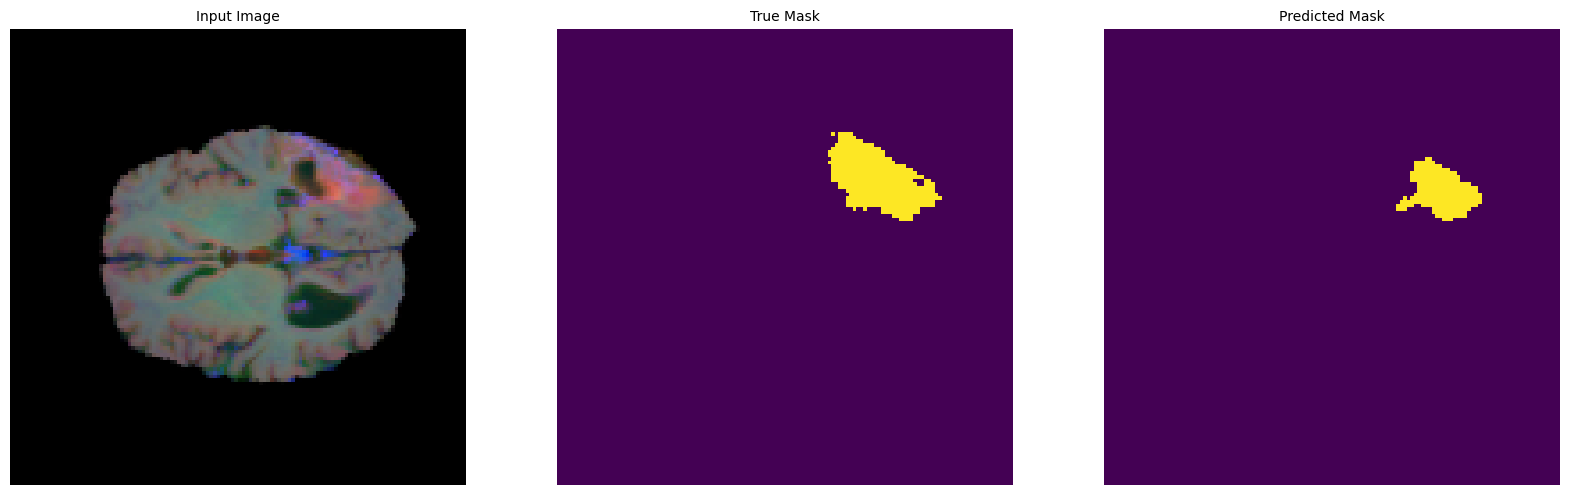

In [125]:
MODEL_SELECTOR = widgets.Dropdown(
    options=CHECKPOINT_PATHS,
    value=None,
    description='Checkpoint:',
    disabled=False,
)

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        print("changed to %s" % change['new'])
        model.load_weights(change['new'])
        pred_mask = model.predict(sample_image_batch)
        clear_output()
        ipy_display(MODEL_SELECTOR)
        imgs.append([sample_image_batch[0], sample_mask_batch[0], create_mask(pred_mask, 0)])
        display([sample_image_batch[0], sample_mask_batch[0], create_mask(pred_mask, 0)])
        
MODEL_SELECTOR.observe(on_change)
ipy_display(MODEL_SELECTOR)

In [ ]:
display(imgs[0] + imgs[1][2:3] + imgs[2][2:3] + imgs[3][2:3] + imgs[4][2:3] + imgs[5][2:3],
        title=['Input Image', 'True Mask', 'Epoch 0', 'Epoch 16', 'Epoch 32', 'Epoch 48', 'Epoch 64', 'Epoch 80'],
        blank=0, rows=2, cols=4, fontsize=25)

In [119]:
imgs_1 = imgs.copy()

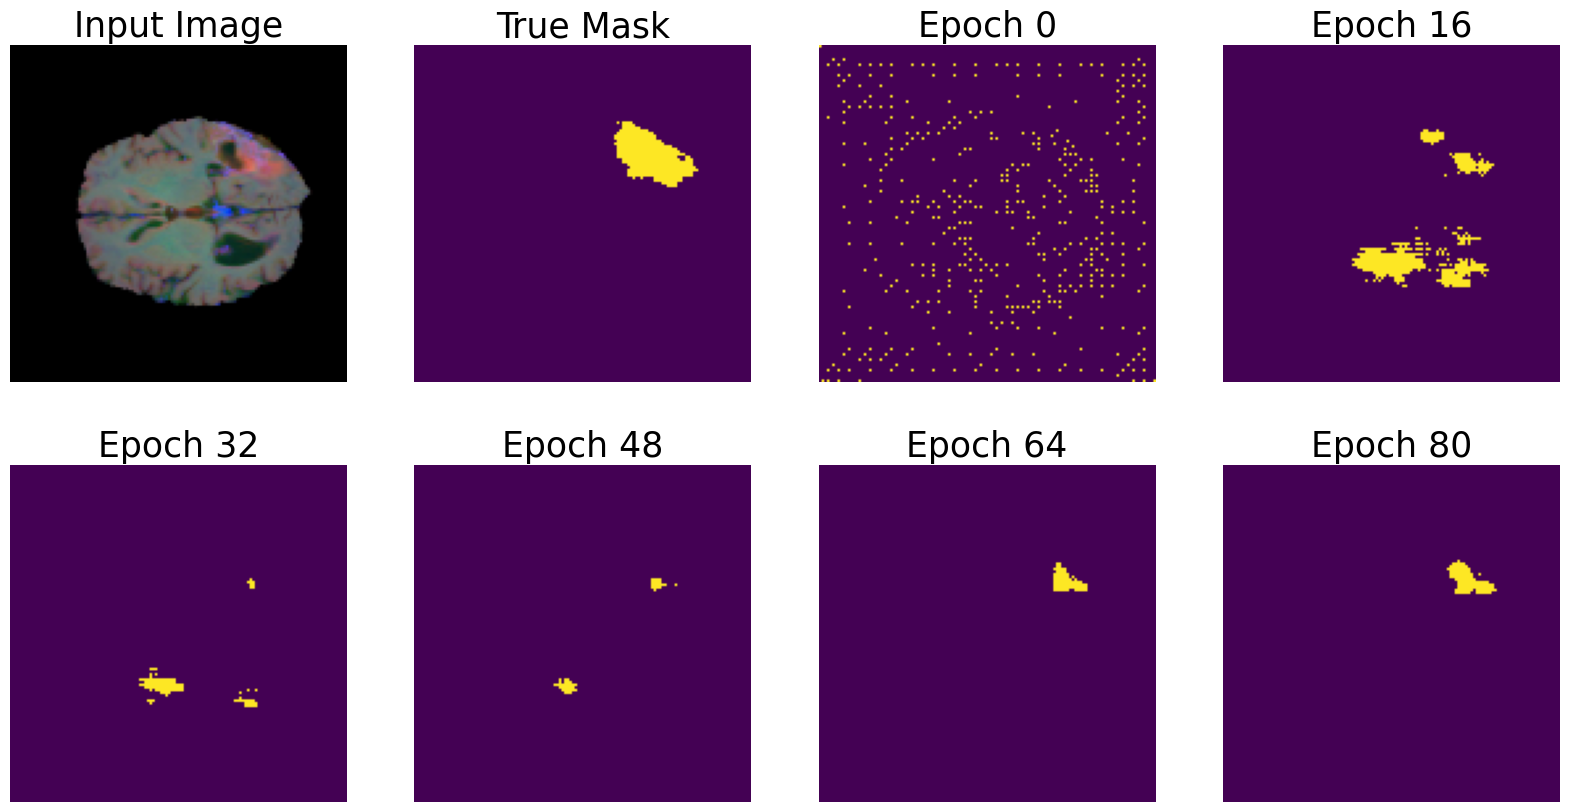

In [88]:
display(imgs[0] + imgs[1][2:3] + imgs[2][2:3] + imgs[3][2:3] + imgs[4][2:3] + imgs[5][2:3],
        title=['Input Image', 'True Mask', 'Epoch 0', 'Epoch 16', 'Epoch 32', 'Epoch 48', 'Epoch 64', 'Epoch 80'],
        rows=2, cols=4, fontsize=25)

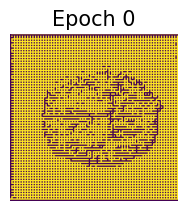

In [ ]:
display(imgs[0][2:3] + imgs[1][2:3] + imgs[2][2:3] + imgs[3][2:3] + imgs[4][2:3] + imgs[5][2:3] + imgs[6][2:3] + imgs[7][2:3] + imgs[8][2:3] + imgs[9][2:3],
        title=['Epoch 0', 'Epoch 4', 'Epoch 8', 'Epoch 12', 'Epoch 16', 'Epoch 0', 'Epoch 4', 'Epoch 8', 'Epoch 12', 'Epoch 16'],
        rows=4, cols=7, fontsize=15, first_img=False)

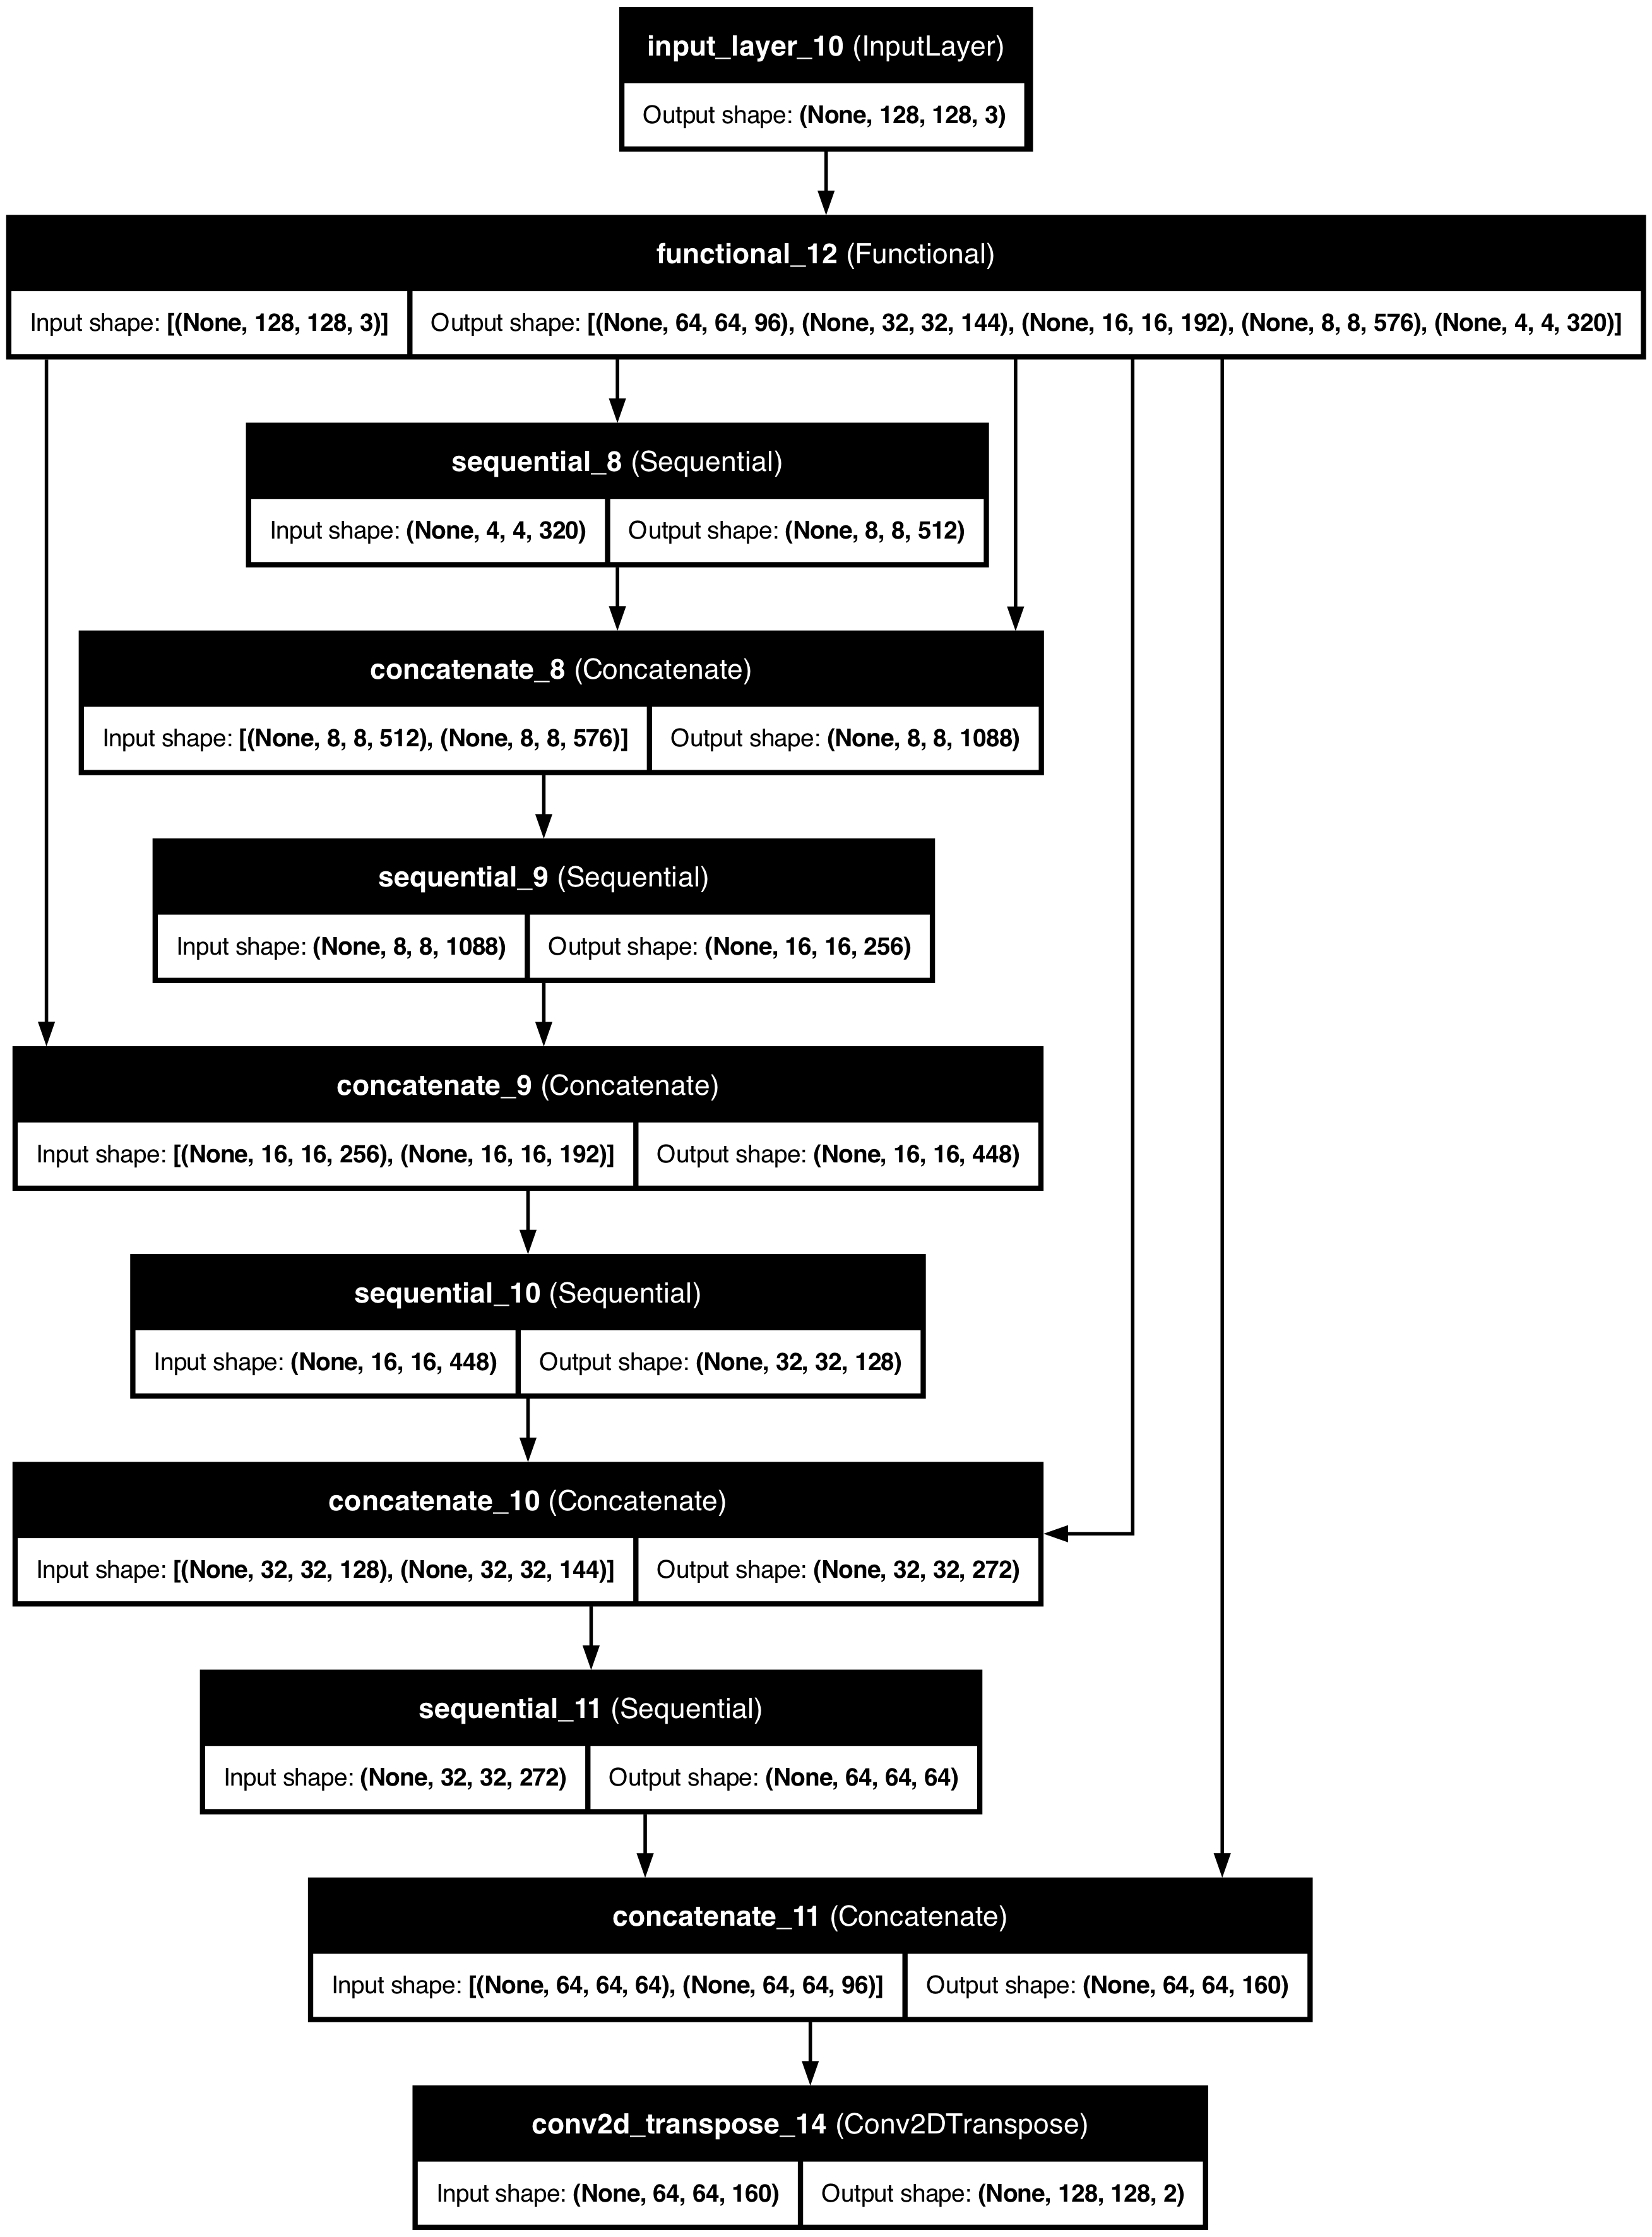

In [52]:
tf.keras.utils.plot_model(
        model,
        to_file='model_architecture.png',   # Name of the output file
        show_shapes=True,                   # Display input/output shapes of layers
        show_layer_names=True               # Display layer names
        
    )